# Round I Data Analysis

# Cell 1 — Imports & data loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Assumes you've cloned Isaac's prosperity3bt fork
DATA_DIR = Path("../../imc-prosperity-3-backtester/prosperity3bt/resources/round1")

# Load prices (semicolon-delimited)
prices = pd.concat([
    pd.read_csv(DATA_DIR / f"prices_round_1_day_{d}.csv", sep=";")
    for d in [-2, -1, 0]
], ignore_index=True)

# Load trades
trades = pd.concat([
    pd.read_csv(DATA_DIR / f"trades_round_1_day_{d}.csv", sep=";")
    for d in [-2, -1, 0]
], ignore_index=True)

osmium = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy()
pepper = prices[prices["product"] == "INTARIAN_PEPPER_ROOT"].copy()

# Global tick index for multi-day plots
for df in [osmium, pepper]:
    df["tick"] = range(len(df))

print(f"Osmium: {len(osmium)} rows, Pepper: {len(pepper)} rows")
print(f"Trades: {len(trades)} rows")

Osmium: 30000 rows, Pepper: 30000 rows
Trades: 2276 rows


# Cell 2 — Mid price overview



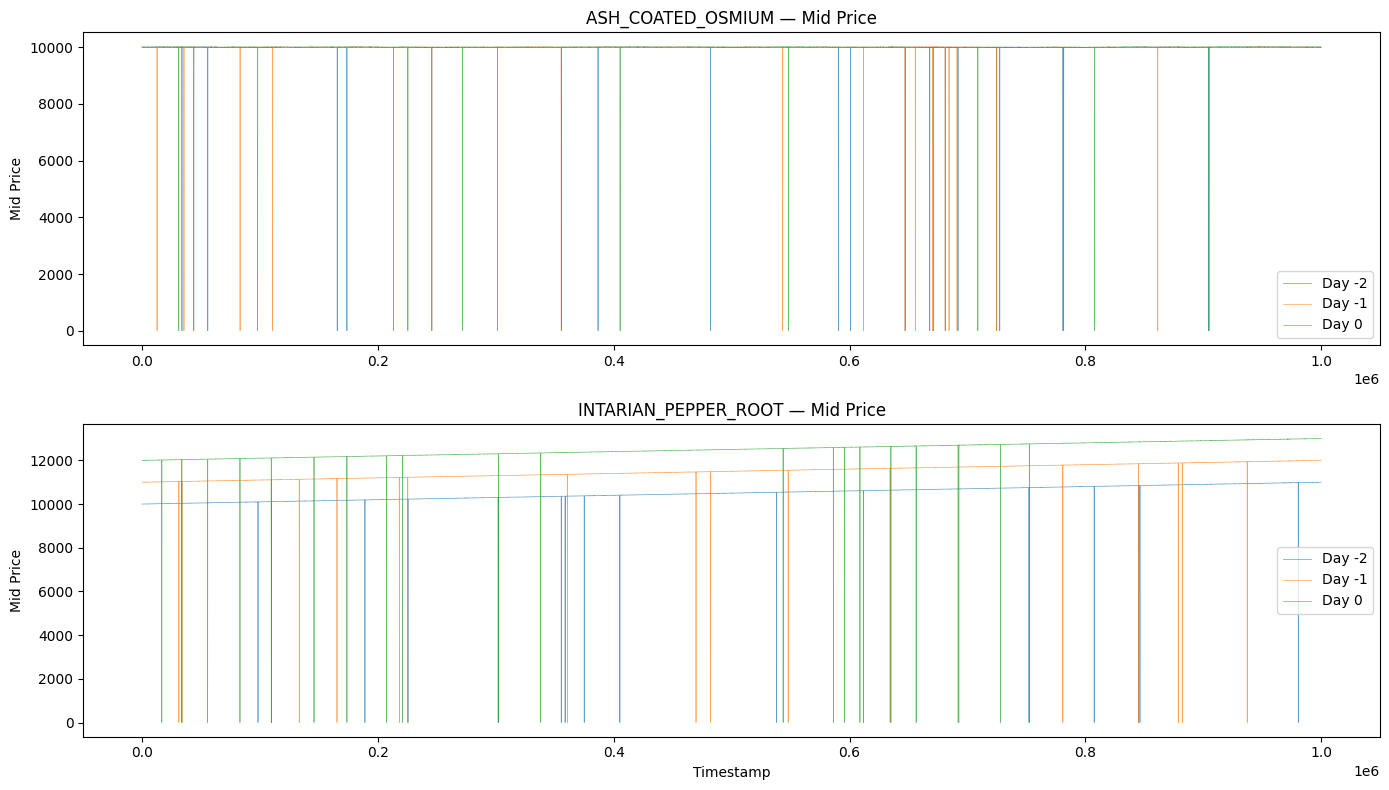

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, df, name in [(axes[0], osmium, "ASH_COATED_OSMIUM"),
                      (axes[1], pepper, "INTARIAN_PEPPER_ROOT")]:
    for day, grp in df.groupby("day"):
        ax.plot(grp["timestamp"], grp["mid_price"], label=f"Day {day}", alpha=0.7, linewidth=0.5)
    ax.set_title(f"{name} — Mid Price")
    ax.set_ylabel("Mid Price")
    ax.legend()

axes[1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

# Cell 3 — Spread distribution



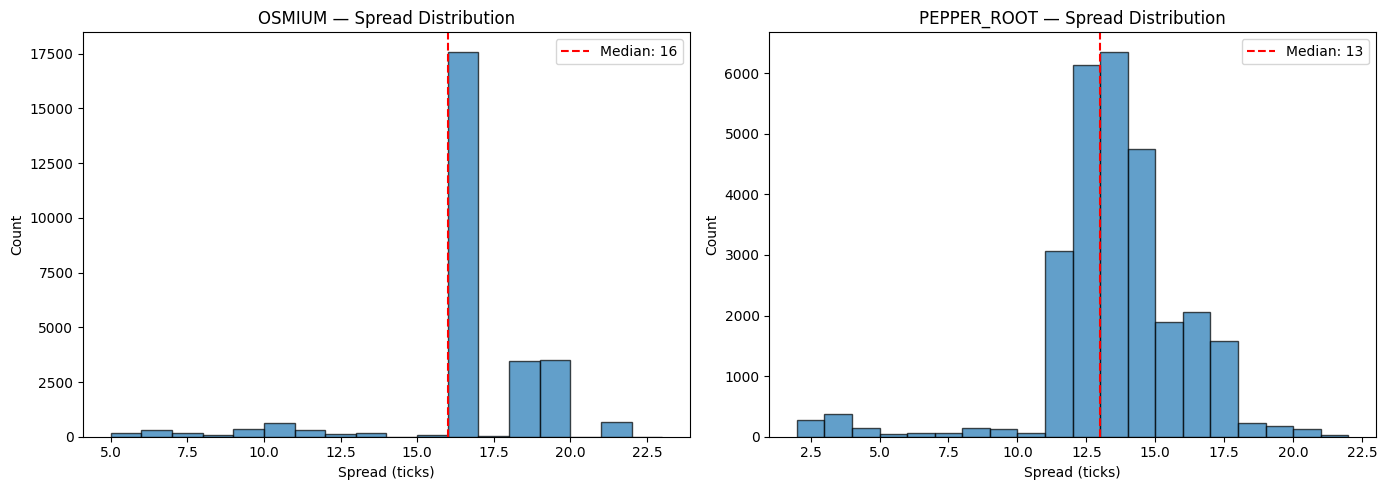

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in [(axes[0], osmium, "OSMIUM"), (axes[1], pepper, "PEPPER_ROOT")]:
    spread = df["ask_price_1"] - df["bid_price_1"]
    spread = spread.dropna()
    ax.hist(spread, bins=range(int(spread.min()), int(spread.max()) + 2), edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} — Spread Distribution")
    ax.set_xlabel("Spread (ticks)")
    ax.set_ylabel("Count")
    ax.axvline(spread.median(), color="red", linestyle="--", label=f"Median: {spread.median():.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

# Cell 4 — Returns & autocorrelation

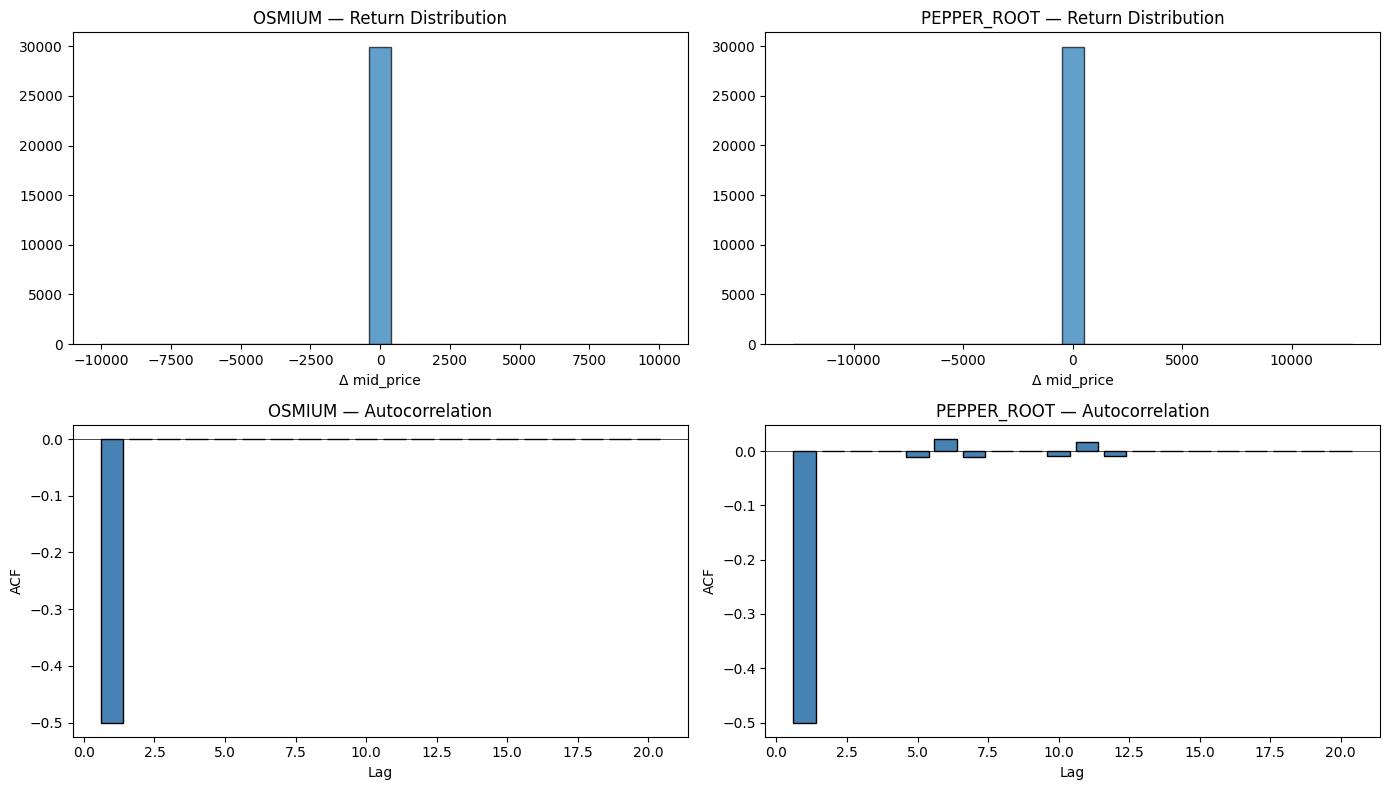

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (df, name) in enumerate([(osmium, "OSMIUM"), (pepper, "PEPPER_ROOT")]):
    returns = df["mid_price"].diff().dropna()

    # Return distribution
    axes[0, col].hist(returns, bins=25, edgecolor="black", alpha=0.7)
    axes[0, col].set_title(f"{name} — Return Distribution")
    axes[0, col].set_xlabel("Δ mid_price")

    # Autocorrelation
    acf = [returns.autocorr(lag=k) for k in range(1, 21)]
    axes[1, col].bar(range(1, 21), acf, color="steelblue", edgecolor="black")
    axes[1, col].axhline(0, color="black", linewidth=0.5)
    axes[1, col].set_title(f"{name} — Autocorrelation")
    axes[1, col].set_xlabel("Lag")
    axes[1, col].set_ylabel("ACF")

plt.tight_layout()
plt.show()

# Cell 5 — OSMIUM deep dive: mean reversion

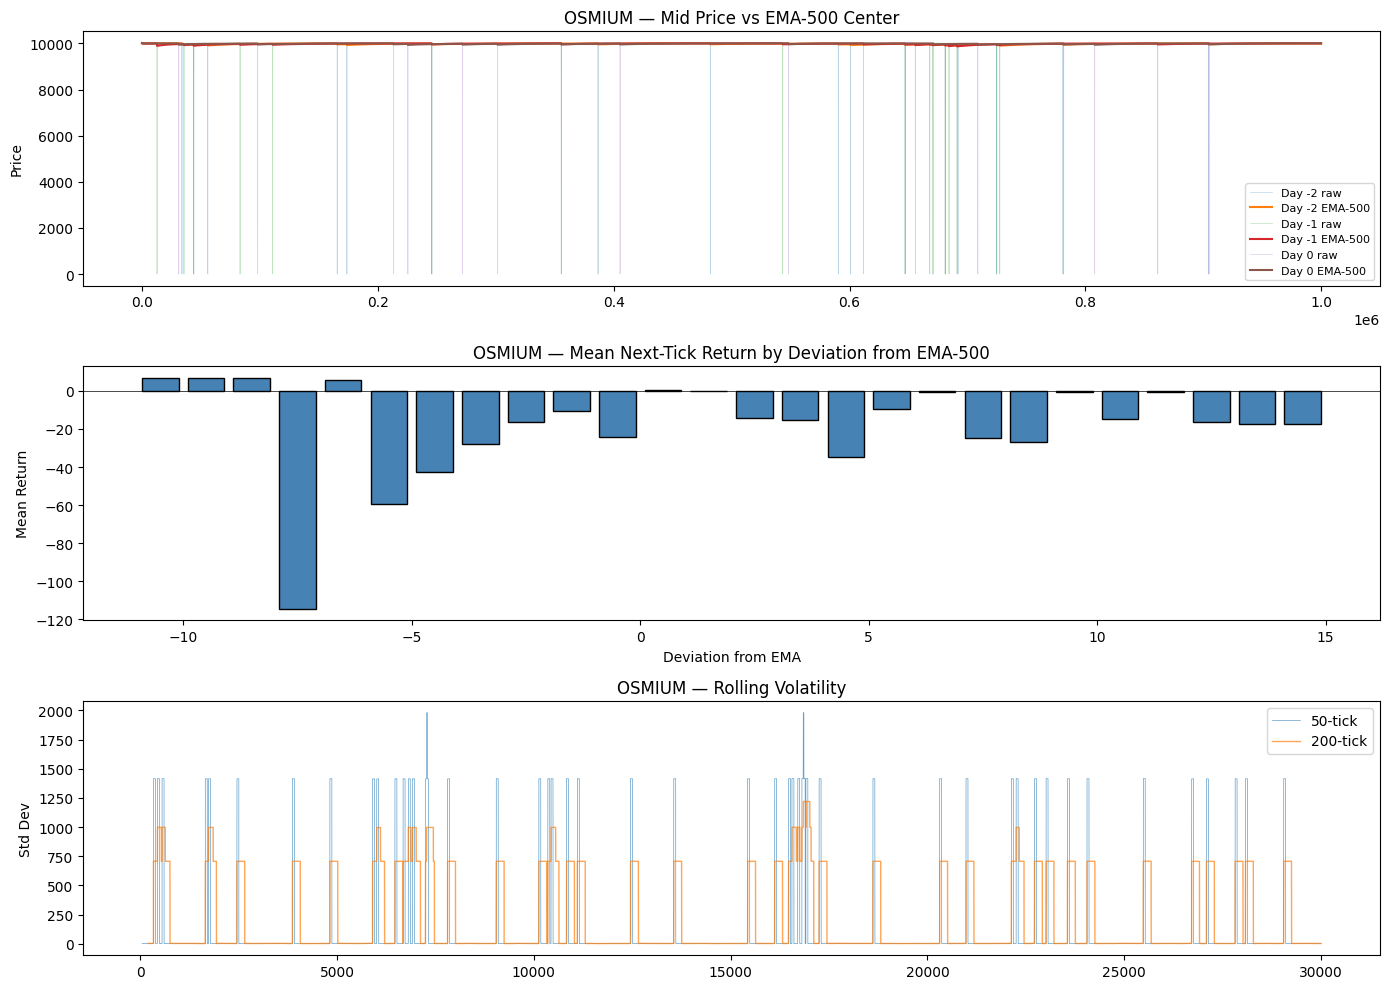

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# EMA center vs raw mid
for day, grp in osmium.groupby("day"):
    mid = grp["mid_price"].values
    # 500-tick EMA
    ema = pd.Series(mid).ewm(span=500).mean().values
    t = grp["timestamp"].values

    axes[0].plot(t, mid, alpha=0.3, linewidth=0.5, label=f"Day {day} raw")
    axes[0].plot(t, ema, linewidth=1.5, label=f"Day {day} EMA-500")

axes[0].set_title("OSMIUM — Mid Price vs EMA-500 Center")
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Price")

# Deviation from EMA → next-tick return
mid_all = osmium["mid_price"].values
ema_all = pd.Series(mid_all).ewm(span=500).mean().values
deviation = mid_all - ema_all
next_return = np.diff(mid_all)

dev = deviation[:-1]  # align with next_return
bins = np.linspace(-15, 15, 31)
bin_idx = np.digitize(dev, bins)

mean_ret = []
bin_centers = []
for i in range(1, len(bins)):
    mask = bin_idx == i
    if mask.sum() > 20:
        mean_ret.append(next_return[mask].mean())
        bin_centers.append((bins[i-1] + bins[i]) / 2)

axes[1].bar(bin_centers, mean_ret, width=0.8, color="steelblue", edgecolor="black")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("OSMIUM — Mean Next-Tick Return by Deviation from EMA-500")
axes[1].set_xlabel("Deviation from EMA")
axes[1].set_ylabel("Mean Return")

# Rolling volatility
roll_50 = pd.Series(mid_all).rolling(50).std()
roll_200 = pd.Series(mid_all).rolling(200).std()
axes[2].plot(roll_50.values, label="50-tick", alpha=0.7, linewidth=0.5)
axes[2].plot(roll_200.values, label="200-tick", alpha=0.7, linewidth=1)
axes[2].set_title("OSMIUM — Rolling Volatility")
axes[2].legend()
axes[2].set_ylabel("Std Dev")

plt.tight_layout()
plt.show()

# Cell 6 — PEPPER_ROOT deep dive: drift

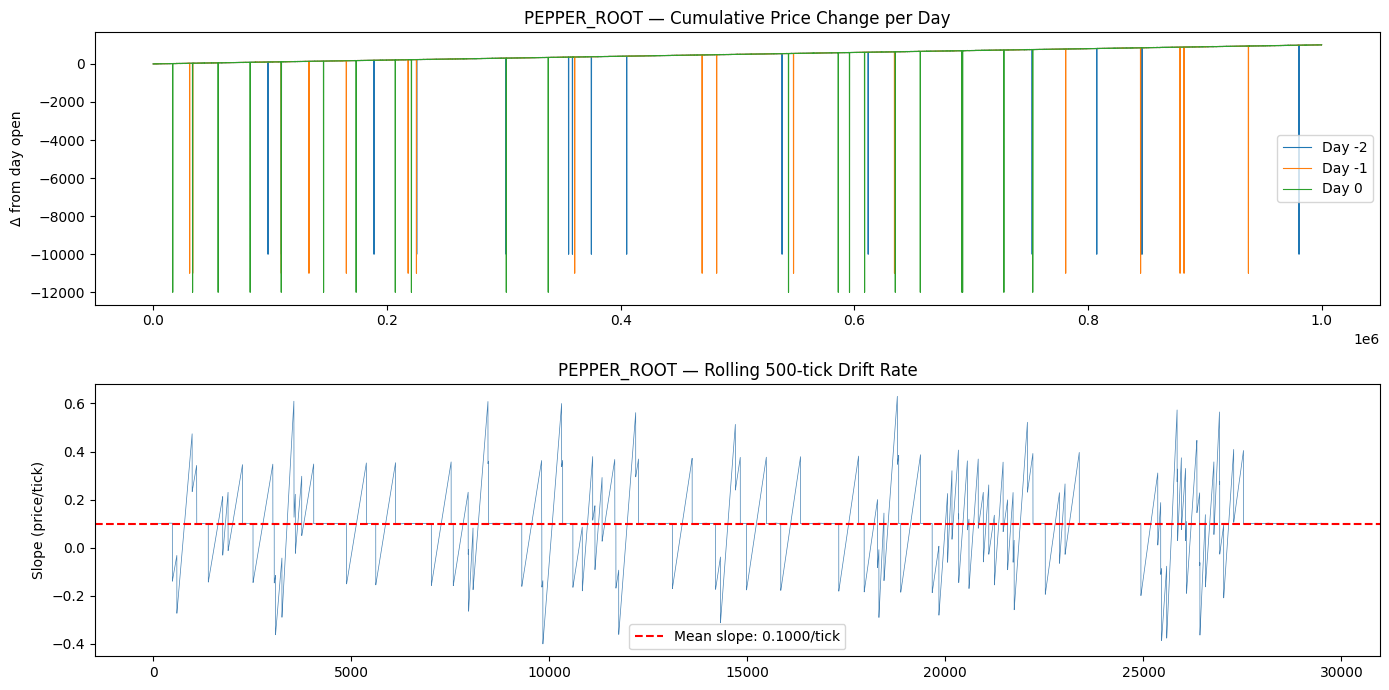

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Cumulative drift per day
for day, grp in pepper.groupby("day"):
    mid = grp["mid_price"].values
    cum_return = mid - mid[0]
    axes[0].plot(grp["timestamp"].values, cum_return, label=f"Day {day}", linewidth=0.8)

axes[0].set_title("PEPPER_ROOT — Cumulative Price Change per Day")
axes[0].set_ylabel("Δ from day open")
axes[0].legend()

# Drift rate (rolling 500-tick slope)
mid_all = pepper["mid_price"].values
slopes = []
window = 500
for i in range(window, len(mid_all)):
    x = np.arange(window)
    y = mid_all[i-window:i]
    slope = np.polyfit(x, y, 1)[0]
    slopes.append(slope)

axes[1].plot(slopes, linewidth=0.5, color="steelblue")
axes[1].axhline(np.mean(slopes), color="red", linestyle="--", label=f"Mean slope: {np.mean(slopes):.4f}/tick")
axes[1].set_title("PEPPER_ROOT — Rolling 500-tick Drift Rate")
axes[1].set_ylabel("Slope (price/tick)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Cell 7 — Trade activity



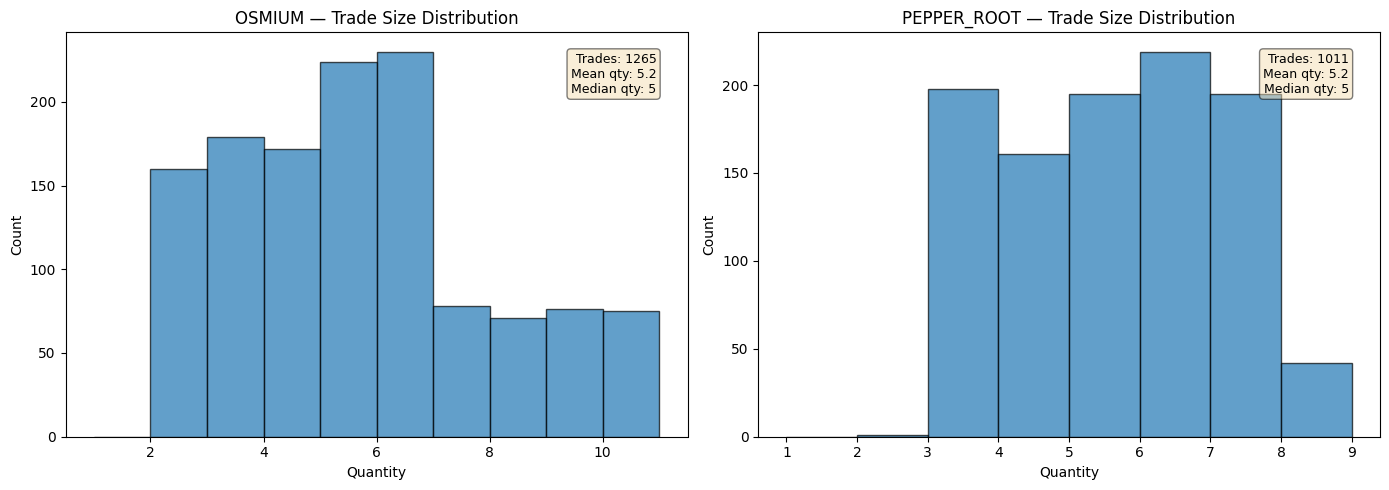

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, symbol, name in [(axes[0], "ASH_COATED_OSMIUM", "OSMIUM"),
                          (axes[1], "INTARIAN_PEPPER_ROOT", "PEPPER_ROOT")]:
    t = trades[trades["symbol"] == symbol]
    ax.hist(t["quantity"], bins=range(1, int(t["quantity"].max()) + 2),
            edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} — Trade Size Distribution")
    ax.set_xlabel("Quantity")
    ax.set_ylabel("Count")

    stats = f"Trades: {len(t)}\nMean qty: {t['quantity'].mean():.1f}\nMedian qty: {t['quantity'].median():.0f}"
    ax.text(0.95, 0.95, stats, transform=ax.transAxes, va="top", ha="right",
            fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

# Cell 8 — Summary stats table

In [17]:
summary = []
for name, df in [("OSMIUM", osmium), ("PEPPER_ROOT", pepper)]:
    mid = df["mid_price"].dropna()
    spread = (df["ask_price_1"] - df["bid_price_1"]).dropna()
    ret = mid.diff().dropna()
    summary.append({
        "Product": name,
        "Mid Mean": f"{mid.mean():.2f}",
        "Mid Std": f"{mid.std():.2f}",
        "Mid Range": f"{mid.max() - mid.min():.0f}",
        "Spread Median": f"{spread.median():.0f}",
        "Drift/tick": f"{ret.mean():.4f}",
        "ACF(1)": f"{ret.autocorr(lag=1):.3f}",
        "Ticks": len(mid),
    })

pd.DataFrame(summary)

,Product,Mid Mean,Mid Std,Mid Range,Spread Median,Drift/tick,ACF(1),Ticks
0,OSMIUM,9983.87,403.87,10023,16,-0.0001,-0.500,30000
1,PEPPER_ROOT,11479.19,993.18,13007,13,0.1001,-0.500,30000
